In [92]:
%pip install pandas numpy scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [93]:
import pandas as pd
df=pd.read_csv("Patna tch.csv")
print(df.head())

   pseudocode  total_tch  male  female  transgender  gen_tch  sc_tch  st_tch  \
0     1000275         85    22      63            0       70       0       0   
1     1002508          1     1       0            0        0       0       0   
2     1002960          2     1       1            0        1       0       0   
3     1004023         27    12      15            0        5       7       0   
4     1004168          2     1       1            0        0       0       0   

   obc_tch  regular  ...  bed_equivalent  med_equivalent  other  none  \
0       15       84  ...              64               3     12     0   
1        1        1  ...               0               0      0     0   
2        1        2  ...               0               0      0     0   
3       10       26  ...              23               3      1     0   
4        2        2  ...               0               0      0     0   

   diploma_special_edu  pursuing_rpc  diploma_ele_edu  early_childhood_tch  \
0 

In [94]:
print(df.columns)
print(df.info())
print(df.describe())

Index(['pseudocode', 'total_tch', 'male', 'female', 'transgender', 'gen_tch',
       'sc_tch', 'st_tch', 'obc_tch', 'regular', 'contract', 'part_time',
       'below_graduate', 'graduate', 'post_graduate_and_above', 'trained_comp',
       'class_taught_pr', 'class_taught_upr', 'class_taught_pr_upr',
       'class_taught_sec_only', 'class_taught_hsec_only',
       'class_taught_upr_sec', 'class_taught_sec_hsec',
       'class_taugt_pre_primary_only', 'class_taught_pr_and_pre_pri',
       'teacher_involve_non_training_assignment', 'diploma_certificate',
       'bachelor_of_ee', 'bed_equivalent', 'med_equivalent', 'other', 'none',
       'diploma_special_edu', 'pursuing_rpc', 'diploma_ele_edu',
       'early_childhood_tch', 'bed_nursery', 'trained_cwsn'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4771 entries, 0 to 4770
Data columns (total 38 columns):
 #   Column                                   Non-Null Count  Dtype
---  ------                             

In [95]:
df.isnull().sum()

pseudocode                                 0
total_tch                                  0
male                                       0
female                                     0
transgender                                0
gen_tch                                    0
sc_tch                                     0
st_tch                                     0
obc_tch                                    0
regular                                    0
contract                                   0
part_time                                  0
below_graduate                             0
graduate                                   0
post_graduate_and_above                    0
trained_comp                               0
class_taught_pr                            0
class_taught_upr                           0
class_taught_pr_upr                        0
class_taught_sec_only                      0
class_taught_hsec_only                     0
class_taught_upr_sec                       0
class_taug

In [96]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [97]:
df.columns = df.columns.str.strip().str.lower()

In [98]:
features = [
    'total_tch',
    'male',
    'female',
    'transgender',
    'gen_tch',
    'sc_tch',
    'st_tch'
]

df = df[features]

In [99]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

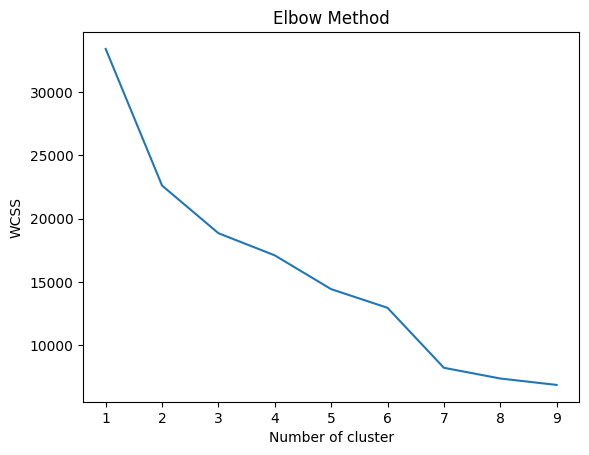

In [100]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss=[]
for i in range(1,10):
    Kmeans = KMeans(n_clusters=i, random_state=42)
    Kmeans.fit(scaled_data)
    wcss.append(Kmeans.inertia_)

plt.plot(range(1,10), wcss)
plt.xlabel("Number of cluster")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [101]:
Kmeans=KMeans(n_clusters=3, random_state=42)
df['Cluster'] = Kmeans.fit_predict(scaled_data)

In [102]:
def label_cluster(x):
    if x==0:
        return "Server Deficit"
    elif x==1:
        return "Moderate Deficit"
    else:
        return "Well Equipped"

df['Deficit Tier']= df['Cluster'].apply(label_cluster)


In [103]:
print(df.head())

   total_tch  male  female  transgender  gen_tch  sc_tch  st_tch  Cluster  \
0         85    22      63            0       70       0       0        2   
1          1     1       0            0        0       0       0        0   
2          2     1       1            0        1       0       0        0   
3         27    12      15            0        5       7       0        1   
4          2     1       1            0        0       0       0        0   

       Deficit Tier  
0     Well Equipped  
1    Server Deficit  
2    Server Deficit  
3  Moderate Deficit  
4    Server Deficit  


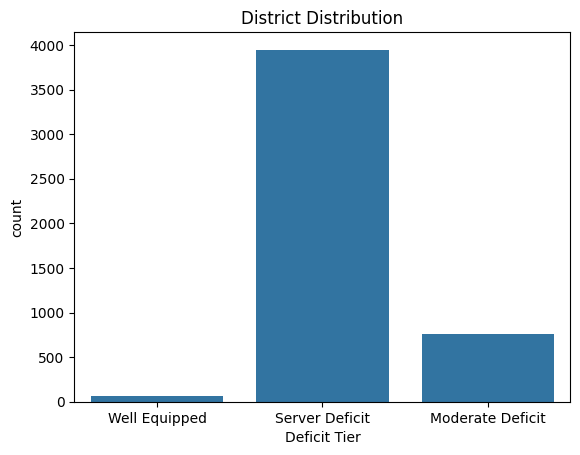

In [104]:
import seaborn as sns

sns.countplot(x='Deficit Tier', data=df)
plt.title("District Distribution")
plt.show()

In [105]:
df.to_csv("Patna tch Cleaned data.csv", index=False)